# Protein and mRNA Overlay

This script is meant to combine the mRNA and protein data using two method
1. First to find the median midpoint and to scale all data based off the location of this midpoint
2. Second is to couch the data. Finding the find vales for x and y and scaling the data.

I also need to fix the problems with the protein data no lining up perfectly. 

## mRNA Data Load

TMA_C_FOV1
Sample ID:TMA_C_FOV1 Xmax = 58.17028799999996, Xmin = 57.42167999999996
Sample ID:TMA_C_FOV1 Ymax = 9.041128, Ymin = 8.292352000000001
TMA_C_FOV2
Sample ID:TMA_C_FOV2 Xmax = 55.68194400000003, Xmin = 54.93451200000003
Sample ID:TMA_C_FOV2 Ymax = 9.406127999999994, Ymin = 8.657687999999993
TMA_C_FOV3
Sample ID:TMA_C_FOV3 Xmax = 58.14128799999996, Xmin = 57.392847999999965
Sample ID:TMA_C_FOV3 Ymax = 5.807288000000005, Ymin = 5.059016000000004
TMA_C_FOV4
Sample ID:TMA_C_FOV4 Xmax = 55.97276799999999, Xmin = 55.22667999999999
Sample ID:TMA_C_FOV4 Ymax = 6.548624000000007, Ymin = 5.799680000000007
TMA_C_FOV5
Sample ID:TMA_C_FOV5 Xmax = 50.005600000000015, Xmin = 49.260016000000014
Sample ID:TMA_C_FOV5 Ymax = 6.676448, Ymin = 5.9296880000000005
TMA_C_FOV6
Sample ID:TMA_C_FOV6 Xmax = 47.85794399999996, Xmin = 47.11067999999996
Sample ID:TMA_C_FOV6 Ymax = 3.447287999999995, Ymin = 2.6993519999999953
TMA_C_FOV7
Sample ID:TMA_C_FOV7 Xmax = 53.010936000000044, Xmin = 52.26518400000005

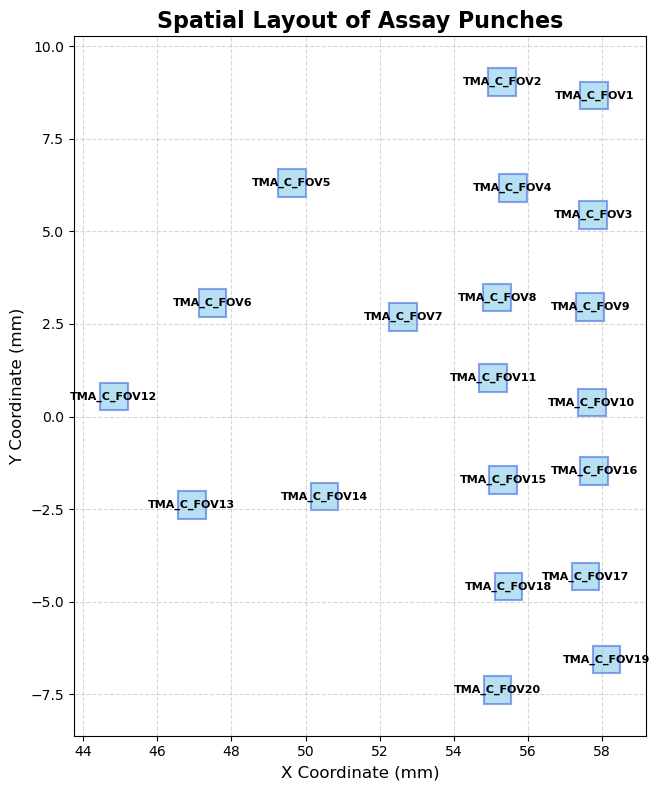

In [28]:

# 2. Process the data to get rectangle coordinates
data=[]
TMA_CORE=["A","B","C"]
for i in range(1,26):
    for j in range(1,2):  # This loop only runs once with j=1
        rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"
        print
        results = find_area_mRNA_global_coords(adata_rna, rna_sample_id)
        dataset="mRNA"

        # Calculate length of dimensions of the samples
        x_length = results["X Max"] - results["X Min"]
        y_length = results["Y Max"] - results["Y Min"]

        data.append({
            "sample_id": rna_sample_id,
            "X Min (mm)": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length,
            "Dataset": dataset
        })

global_rectangles_mRNA = pd.DataFrame(data).dropna()


# 3. Display the resulting DataFrame
print("Calculated Rectangle Coordinates and Dimensions:")
print(global_rectangles_mRNA)


# 4. Generate and show the plot
plot_spatial_rectangles_mRNA2(global_rectangles_mRNA)


In [27]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

TMA_Core="C" # Should be A,B,C 

# #Load files on laptop
# expr= pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
# #expr=expr_orig.transpose()
# metadata = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
# umap = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

#Load files on desktop
# expr= pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
# #expr=expr_orig.transpose()
# metadata = pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
# umap = pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

#Load files on laptop
expr= pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
#expr=expr_orig.transpose()
metadata = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
umap = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

# Extra - MetaData File
extra_metadata=pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\Run_TMA{TMA_Core}_metadata_file.csv", index_col=0)

# Create AnnData object
adata_rna = sc.AnnData(X=expr.values)

# Assign metadata
adata_rna.obs = metadata
adata_rna.var_names = expr.columns
adata_rna.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
adata_rna.obsm["spatial"] = metadata[['x_pixel', 'y_pixel']].values  # adjust if needed
# x_pixel, y_pixel, x_norm	y_norm	x_micron	y_micron x_cent	y_cent

adata_rna.obsm["X_umap"] = umap.values